# NB01: Data Integration & Exploratory Data Analysis

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Load all PROTECT Gold tables, merge into an analysis-ready master dataset, and provide a thorough EDA so the audience understands the data going into downstream analyses.

## Sections
1. Load all data tables
2. Isolate catalog characterization
3. Patient cohort overview
4. Inhibition landscape
5. Carbon utilization profiling (with PA14 reference)
6. Data coverage & overlap
7. Build master analysis table

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Paths
GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('..') / 'data'
FIGS = Path('..') / 'figures'
DATA.mkdir(exist_ok=True)
FIGS.mkdir(exist_ok=True)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print('Ready.')

Ready.


## 1. Load All Data Tables

The PROTECT CF Synbiotic Cocktail Study produced **23 Gold tables** (30.5M rows total) covering:
- Isolate catalog and patient metadata (dimensions)
- Inhibition assays, carbon utilization, growth kinetics (facts)
- Patient metagenomics and metatranscriptomics
- KEGG pathway expression and PA competitor scores

In [2]:
# Load all tables
tables = {}
for f in sorted(GOLD.glob('*.snappy.parquet')):
    name = f.stem.replace('.snappy', '')
    tables[name] = pd.read_parquet(f)

print(f'Loaded {len(tables)} tables:\n')
summary = []
for name, df in sorted(tables.items()):
    summary.append({'table': name, 'rows': len(df), 'columns': len(df.columns)})
pd.DataFrame(summary).to_string(index=False)

Loaded 23 tables:



'                            table     rows  columns\n      bridge_isolate_metagenomics      186        5\n        dict_patient_status_codes        7        3\n         dim_candidate_prebiotics      431        7\n                      dim_isolate     4949       21\n               dim_patient_sample      175       25\n             fact_abundance_genus    12529        3\n  fact_abundance_genus_stratified 12665785        4\n           fact_abundance_species    25058        3\nfact_abundance_species_stratified 13843636        4\n          fact_carbon_utilization      826       24\n           fact_competition_assay     1584       10\n                fact_growth_curve    17346        5\n         fact_growth_curves_clean   267305        5\n        fact_growth_curves_fitted   676000        5\n          fact_inhibition_control      826       24\n           fact_inhibition_scores      722        6\n                fact_kegg_pathway   559326        4\n                   fact_metag_cpm     9916   

In [3]:
# Assign convenient names
isolates = tables['dim_isolate']
patients = tables['dim_patient_sample']
status_codes = tables['dict_patient_status_codes']
inhibition = tables['fact_inhibition_scores']
carbon_util = tables['fact_carbon_utilization']
growth_fitted = tables['fact_growth_curves_fitted']
growth_clean = tables['fact_growth_curves_clean']
growth_summary = tables['fact_growth_curve']
competition = tables['fact_competition_assay']
pairwise = tables['fact_pairwise_interaction']
inhib_control = tables['fact_inhibition_control']
pa_competitors = tables['fact_pa_competitors']
prebiotics = tables['dim_candidate_prebiotics']
abund_species = tables['fact_abundance_species']
metag_cpm = tables['fact_metag_cpm']
metars_cpm = tables['fact_metars_cpm']
kegg_pathway = tables['fact_kegg_pathway']
sp_kegg_cpm = tables['fact_species_kegg_pathway_cpm']
bridge = tables['bridge_isolate_metagenomics']

print('Tables assigned.')

Tables assigned.


---
## 2. Isolate Catalog

The PROTECT study collected **4,949 isolates** from CF and NCFB patient samples. Each has:
- Full GTDB taxonomy (domain → species)
- Genome assembly quality (BUSCO, CheckM2, contamination)
- Closest reference genome with ANI
- Strain group assignment and representative flag

In [4]:
print(f'Total isolates: {len(isolates)}')
print(f'Unique species: {isolates.species.nunique()}')
print(f'Unique genera: {isolates.genus.nunique()}')
print(f'Unique strain groups: {isolates.strain_group.nunique()}')
print(f'\nRepresentative status:')
print(isolates.representative.value_counts().to_string())
print(f'\nGenome quality (CheckM2 completeness):')
comp = pd.to_numeric(isolates.completeness_checkm2, errors='coerce')
print(f'  Mean: {comp.mean():.1f}%  Median: {comp.median():.1f}%  Min: {comp.min():.1f}%')
contam = pd.to_numeric(isolates.contamination_checkm2, errors='coerce')
print(f'Contamination: Mean: {contam.mean():.2f}%  Median: {contam.median():.2f}%  Max: {contam.max():.2f}%')

Total isolates: 4949
Unique species: 211
Unique genera: 51
Unique strain groups: 729

Representative status:
representative
No               3526
Yes               734
Not clustered     689

Genome quality (CheckM2 completeness):
  Mean: 99.8%  Median: 100.0%  Min: 0.0%
Contamination: Mean: 8.93%  Median: 0.13%  Max: 508.15%


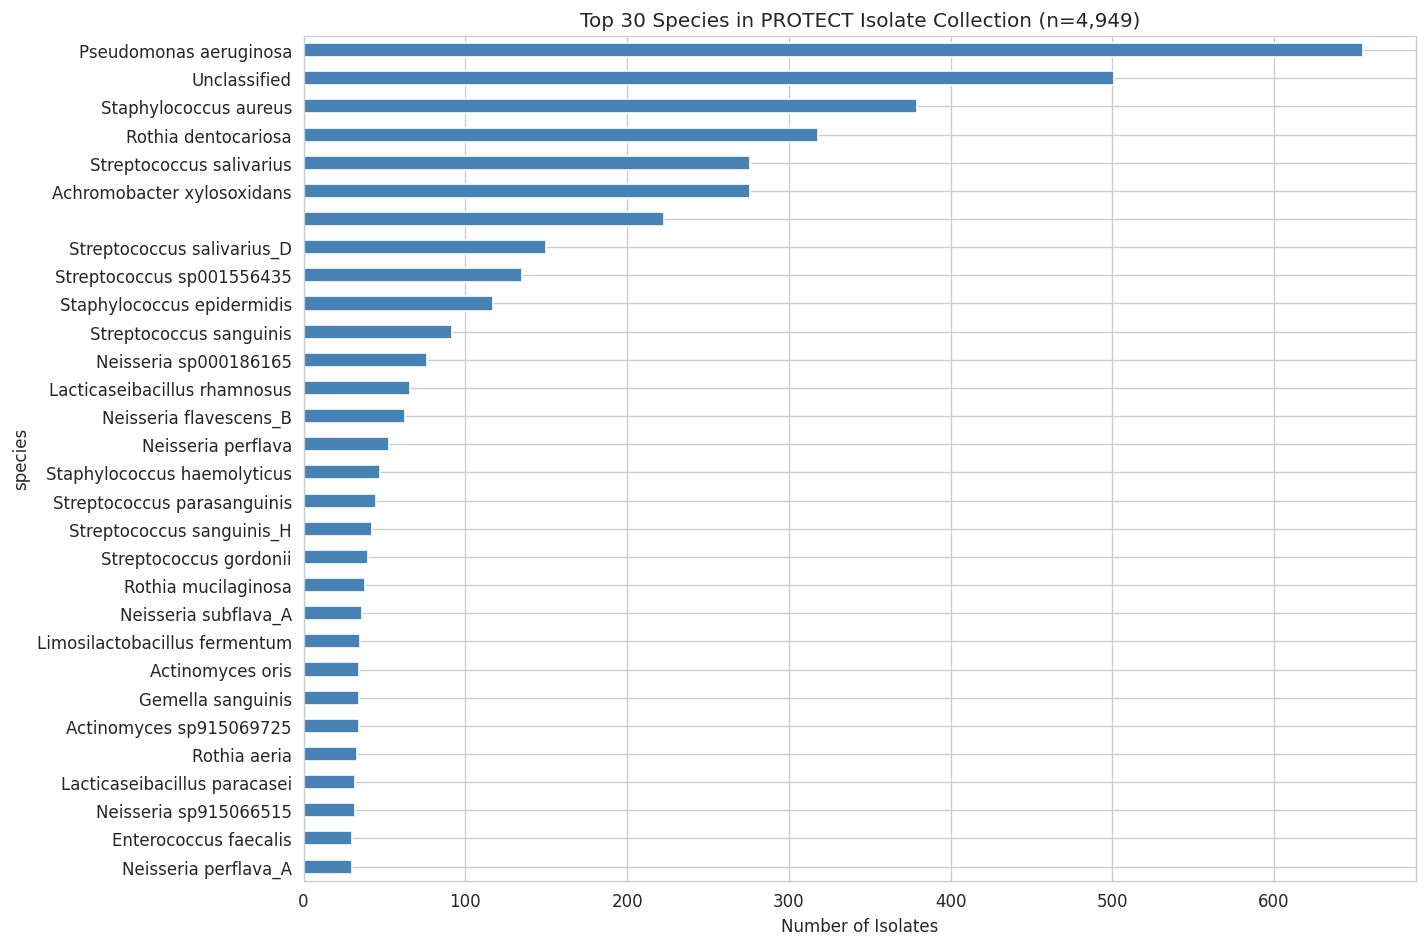

In [5]:
# Species distribution — top 30
fig, ax = plt.subplots(figsize=(12, 8))
sp_counts = isolates.species.value_counts().head(30)
sp_counts.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Number of Isolates')
ax.set_title('Top 30 Species in PROTECT Isolate Collection (n=4,949)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGS / '01_isolate_species_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

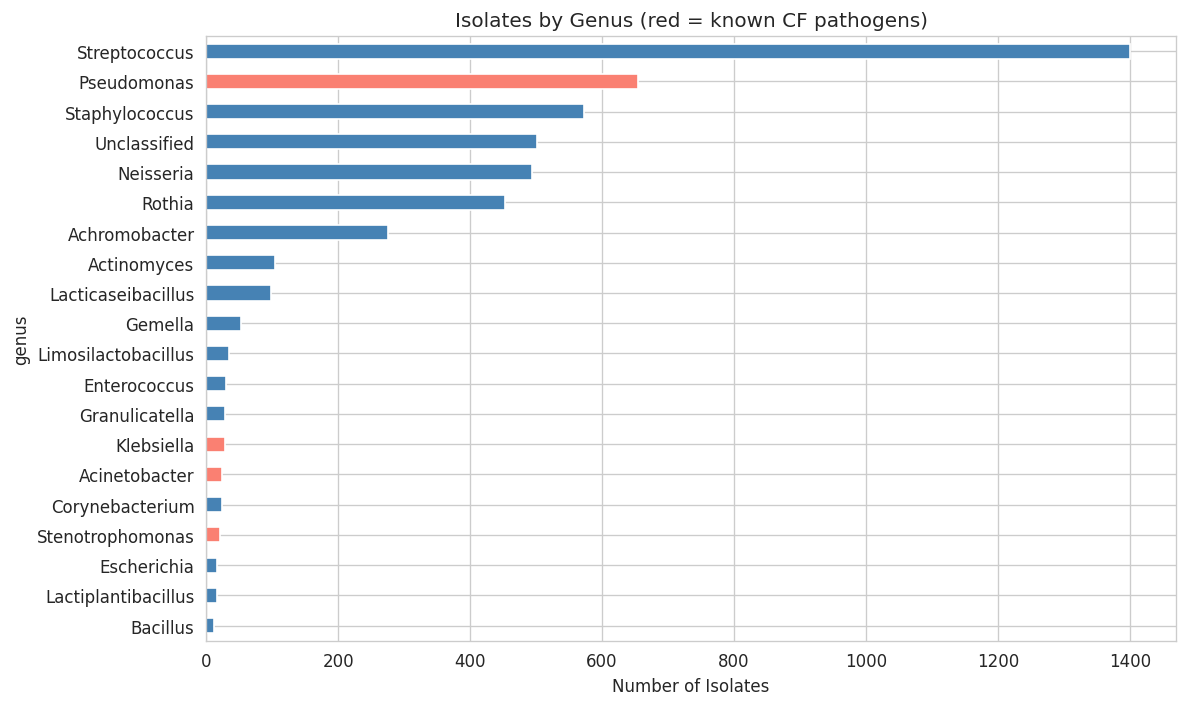

In [6]:
# Genus-level distribution
fig, ax = plt.subplots(figsize=(10, 6))
genus_counts = isolates.genus.value_counts().head(20)
colors = ['salmon' if g in ['Pseudomonas', 'Klebsiella', 'Acinetobacter', 'Stenotrophomonas'] 
          else 'steelblue' for g in genus_counts.index]
genus_counts.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Number of Isolates')
ax.set_title('Isolates by Genus (red = known CF pathogens)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGS / '01_isolate_genus_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

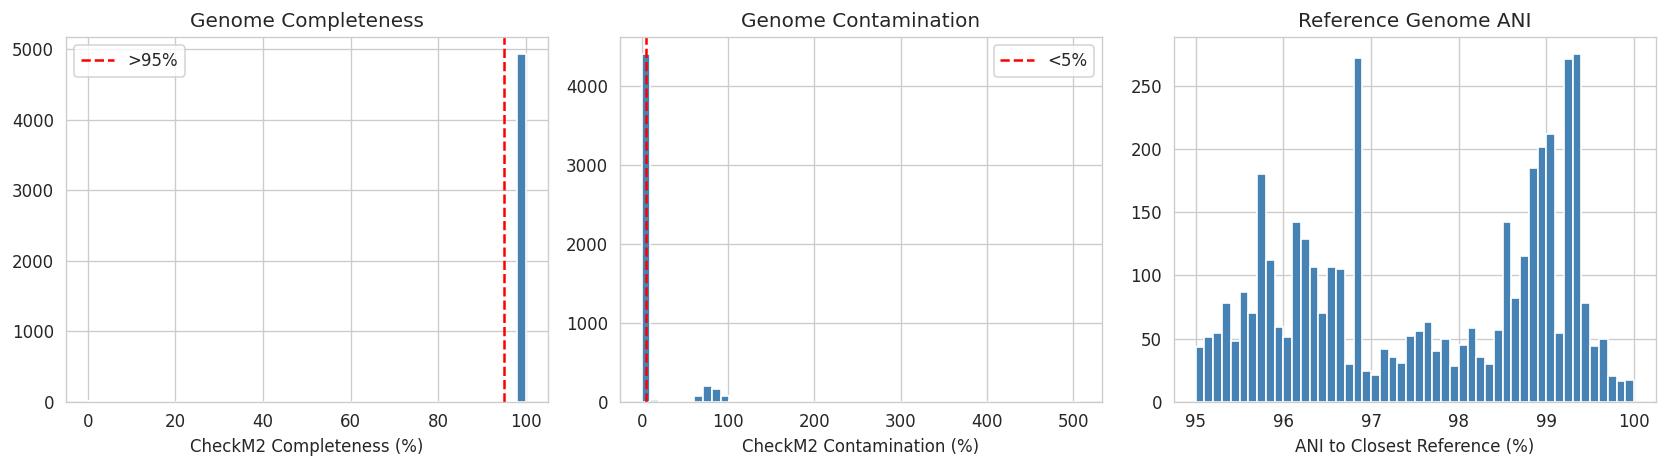

High quality (>=95% complete, <5% contam): 4374 / 4949


In [7]:
# Genome quality overview
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
comp.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('CheckM2 Completeness (%)')
ax.set_title('Genome Completeness')
ax.axvline(95, color='red', ls='--', label='>95%')
ax.legend()

ax = axes[1]
contam.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('CheckM2 Contamination (%)')
ax.set_title('Genome Contamination')
ax.axvline(5, color='red', ls='--', label='<5%')
ax.legend()

ax = axes[2]
ani = pd.to_numeric(isolates.closest_genome_ani, errors='coerce')
ani.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('ANI to Closest Reference (%)')
ax.set_title('Reference Genome ANI')

plt.tight_layout()
plt.savefig(FIGS / '01_genome_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'High quality (>=95% complete, <5% contam): {((comp >= 95) & (contam < 5)).sum()} / {len(isolates)}')

---
## 3. Patient Cohort

175 samples from CF and NCFB (non-CF bronchiectasis) patients across 4 clinical states:
- **A**: Untreated acute exacerbation
- **B**: Acute exacerbation under treatment
- **C**: End of treatment
- **D**: Stable (2 weeks post-antibiotics)

In [8]:
print(f'Total patient samples: {len(patients)}')
print(f'Unique subjects: {patients.subject_id.nunique()}')
print(f'\nDiagnosis:')
print(patients.diagnosis.value_counts().to_string())
print(f'\nPatient status:')
# Extract letter code from patient_status
patients['status_letter'] = patients.patient_status.str[0]
print(patients.status_letter.value_counts().sort_index().to_string())
print(f'\nSample types (freeze_status):')
print(patients.freeze_status.str.strip().value_counts().to_string())

Total patient samples: 175
Unique subjects: 43

Diagnosis:
diagnosis
CF      133
NCFB     41

Patient status:
status_letter
A    31
B    45
C    15
D    84

Sample types (freeze_status):
freeze_status
Home Fz        80
Fs             38
Mouth Rinse    33
Fs-Fz          20
Fz              4


In [9]:
# Pathogen colonization from clinical microbiology
pathogen_cols = ['pseudomonas_aeruginosa', 'staphylococcus_aureus', 
                 'alcaligenes_achromobacter_xylosoxidans', 
                 'stenotrophomonas_xanthomonas_maltophilia',
                 'escherichia_coli', 'streptococcus_pneumoniae',
                 'aspergillus_any_species', 'm_abscessus']

colonization = patients[pathogen_cols].notna().sum().sort_values(ascending=False)
print('Pathogen detection frequency (number of samples positive):')
print(colonization.to_string())

# PA mucoid status among PA-positive
pa_pos = patients[patients.pseudomonas_aeruginosa.notna()]
print(f'\nPA mucoid status (n={len(pa_pos)} PA+ samples):')
print(pa_pos.pseudomonas_aeruginosa_mucoid_status.value_counts().to_string())

Pathogen detection frequency (number of samples positive):
pseudomonas_aeruginosa                      36
alcaligenes_achromobacter_xylosoxidans      17
staphylococcus_aureus                       13
escherichia_coli                             7
aspergillus_any_species                      7
stenotrophomonas_xanthomonas_maltophilia     4
m_abscessus                                  4
streptococcus_pneumoniae                     3

PA mucoid status (n=36 PA+ samples):
pseudomonas_aeruginosa_mucoid_status
mucoid                26
mucoid, non-mucoid     5
non-mucoid             5


---
## 4. Inhibition Landscape

The key outcome variable: **% inhibition of PA14** measured under different reporter starting OD and gain settings. 220 isolates tested across 91 species.

In [10]:
# Convert types
inhibition['pct_inh'] = pd.to_numeric(inhibition['mean_pct_inhibition'], errors='coerce')
inhibition['sd_inh'] = pd.to_numeric(inhibition['sd_pct_inhibition'], errors='coerce')

print(f'Inhibition measurements: {len(inhibition)}')
print(f'Unique isolates: {inhibition.asma_id.nunique()}')
print(f'Conditions tested: {inhibition[["reporter_starting_od","gain"]].drop_duplicates().shape[0]}')
print(f'\nInhibition distribution:')
print(inhibition.pct_inh.describe().to_string())
print(f'\nNegative inhibition (growth promotion): {(inhibition.pct_inh < 0).sum()} measurements')
print(f'Strong inhibition (>50%): {(inhibition.pct_inh > 50).sum()} measurements')

Inhibition measurements: 722
Unique isolates: 220
Conditions tested: 7

Inhibition distribution:
count    722.000000
mean      16.039635
std       27.849605
min      -63.310643
25%        0.308475
50%       17.095416
75%       30.122512
max      101.603699

Negative inhibition (growth promotion): 179 measurements
Strong inhibition (>50%): 58 measurements


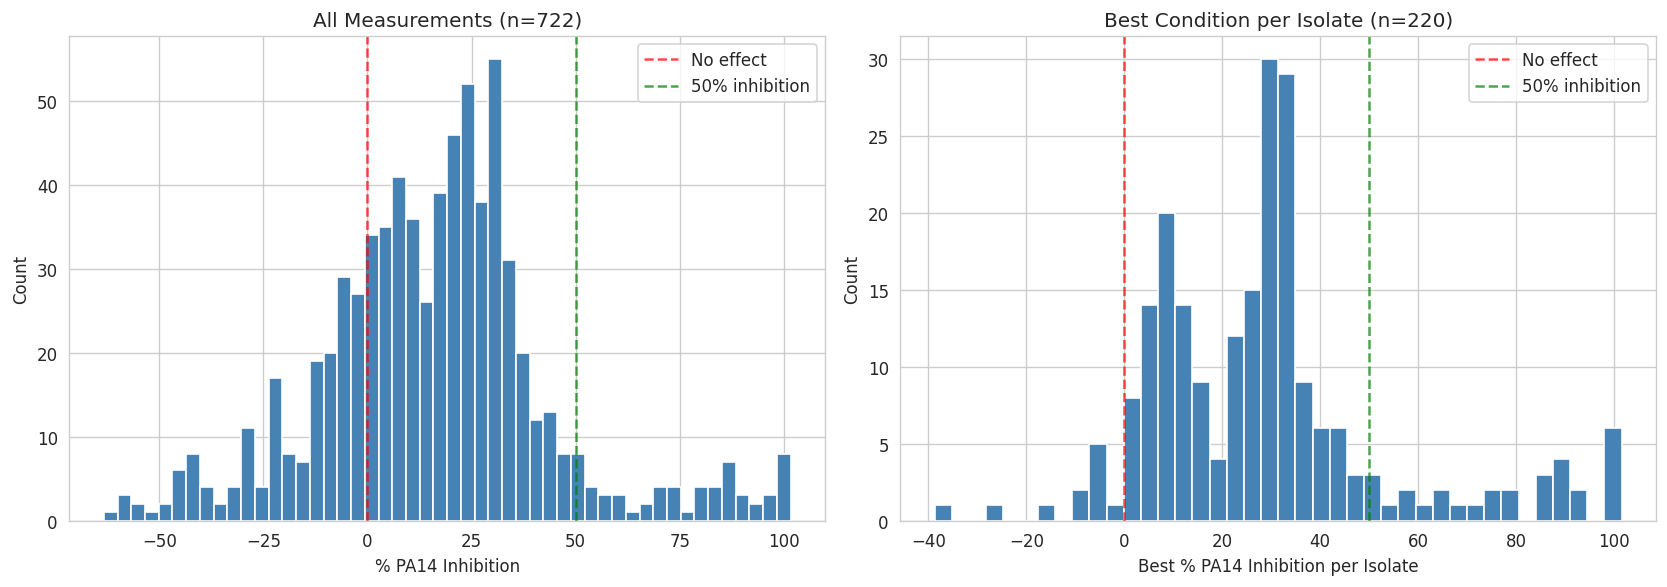

In [11]:
# Distribution of inhibition scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All measurements
ax = axes[0]
inhibition.pct_inh.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', ls='--', alpha=0.7, label='No effect')
ax.axvline(50, color='green', ls='--', alpha=0.7, label='50% inhibition')
ax.set_xlabel('% PA14 Inhibition')
ax.set_ylabel('Count')
ax.set_title(f'All Measurements (n={len(inhibition)})')
ax.legend()

# Best per isolate
ax = axes[1]
best_inh = inhibition.groupby('asma_id')['pct_inh'].max()
best_inh.hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', ls='--', alpha=0.7, label='No effect')
ax.axvline(50, color='green', ls='--', alpha=0.7, label='50% inhibition')
ax.set_xlabel('Best % PA14 Inhibition per Isolate')
ax.set_ylabel('Count')
ax.set_title(f'Best Condition per Isolate (n={len(best_inh)})')
ax.legend()

plt.tight_layout()
plt.savefig(FIGS / '01_inhibition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Inhibition by species — merge with taxonomy
inh_tax = inhibition.merge(isolates[['asma_id', 'species', 'genus']], on='asma_id', how='left')
best_by_species = inh_tax.groupby('asma_id').agg(
    best_inh=('pct_inh', 'max'),
    species=('species', 'first'),
    genus=('genus', 'first')
).reset_index()

# Species with >= 3 isolates tested
sp_stats = best_by_species.groupby('species').agg(
    n=('best_inh', 'count'),
    mean_inh=('best_inh', 'mean'),
    max_inh=('best_inh', 'max'),
    min_inh=('best_inh', 'min')
).query('n >= 3').sort_values('mean_inh', ascending=False)

print(f'Species with >= 3 isolates tested ({len(sp_stats)}):')
print(sp_stats.round(1).to_string())

Species with >= 3 isolates tested (20):
                                n  mean_inh  max_inh  min_inh
species                                                      
Streptococcus salivarius        7      70.6    100.1     30.1
Gemella sanguinis               6      40.9     85.0     31.0
Weissella cibaria               7      33.1     39.3     30.2
Staphylococcus capitis          3      32.4     53.0     22.1
Neisseria sp000186165           4      31.1     43.3     17.0
Actinomyces naeslundii          3      30.5     58.0      7.5
Lacticaseibacillus rhamnosus    3      30.2     32.6     27.5
Lactiplantibacillus plantarum   7      30.0     32.5     25.4
Lacticaseibacillus paracasei    5      30.0     34.8     26.0
Actinomyces oris                3      27.4     65.3      8.3
Streptococcus oralis_S          3      25.4     28.1     23.8
Limosilactobacillus fermentum   3      24.9     31.2     14.0
Staphylococcus epidermidis      9      23.6     99.1     -3.8
Streptococcus anginosus       

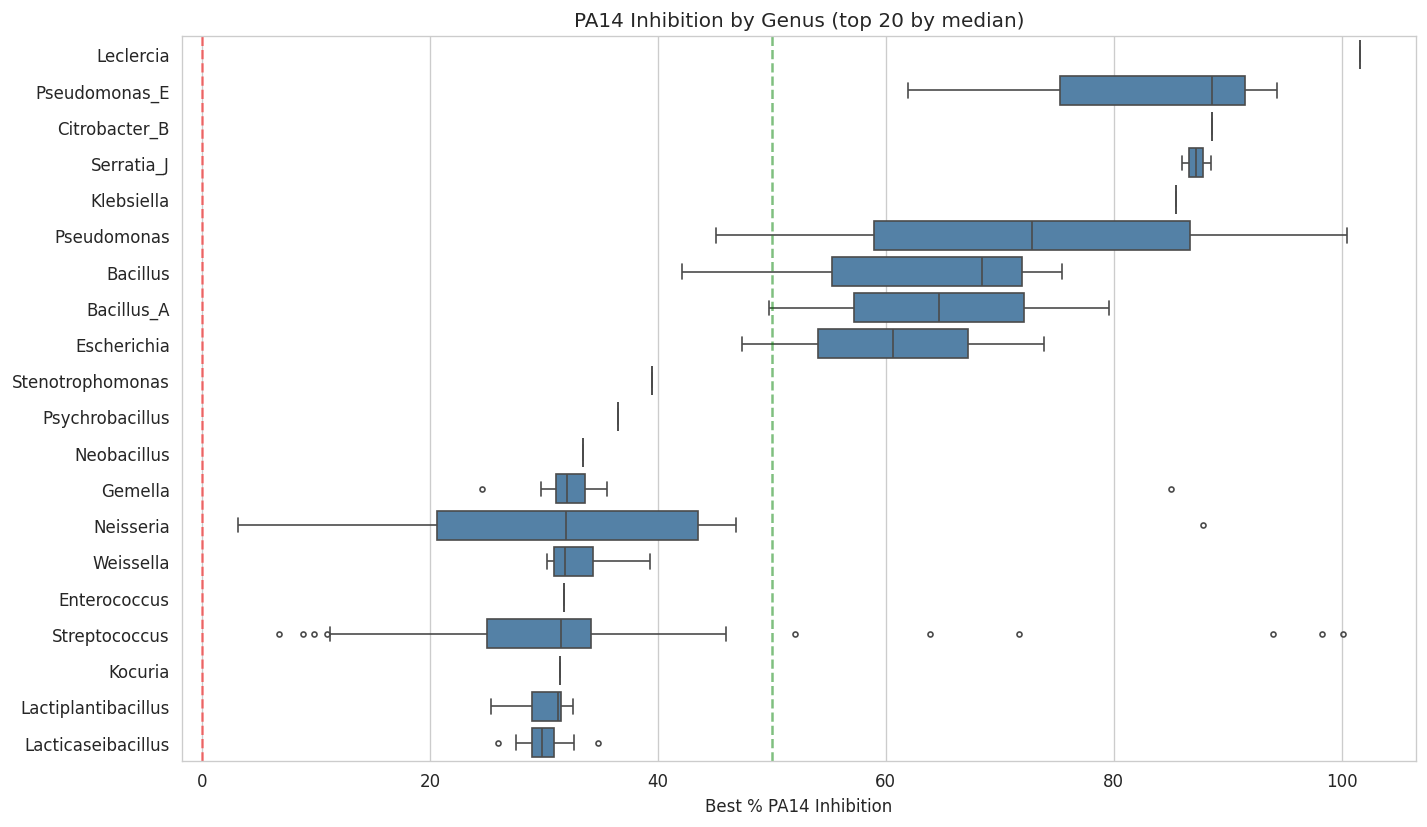

In [13]:
# Inhibition by genus — boxplot
genus_order = best_by_species.groupby('genus')['best_inh'].median().sort_values(ascending=False)
top_genera = genus_order.head(20).index.tolist()
plot_data = best_by_species[best_by_species.genus.isin(top_genera)]

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=plot_data, y='genus', x='best_inh', order=top_genera,
            color='steelblue', fliersize=3, ax=ax)
ax.axvline(0, color='red', ls='--', alpha=0.5)
ax.axvline(50, color='green', ls='--', alpha=0.5)
ax.set_xlabel('Best % PA14 Inhibition')
ax.set_ylabel('')
ax.set_title('PA14 Inhibition by Genus (top 20 by median)')
plt.tight_layout()
plt.savefig(FIGS / '01_inhibition_by_genus.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Carbon Utilization Profiling

430 isolates (plus reporters) tested on **21 carbon sources**: no_carbon (negative control), glucose, lactate, and 18 amino acids. Values are endpoint OD — higher = more growth.

In [14]:
carbon_sources = ['no_carbon', 'glucose', 'lactate', 'serine', 'threonine', 'alanine',
                  'glycine', 'proline', 'isoleucine', 'leucine', 'valine', 'aspartate',
                  'glutamate', 'phenylalanine', 'tryptophan', 'lysine', 'histidine',
                  'arginine', 'ornithine', 'cystein', 'methionine']

# Convert to numeric
cu_numeric = carbon_util.copy()
for col in carbon_sources:
    cu_numeric[col] = pd.to_numeric(cu_numeric[col], errors='coerce')

print(f'Total rows: {len(cu_numeric)}')
print(f'Unique isolates: {cu_numeric.asma_id.nunique()}')
# Separate reporters from candidates
reporters = cu_numeric[cu_numeric.asma_id.str.contains('Reporter|PA14|reporter', case=False, na=False)]
candidates = cu_numeric[~cu_numeric.asma_id.str.contains('Reporter|PA14|reporter', case=False, na=False)]
print(f'Reporter isolates: {reporters.asma_id.nunique()} ({len(reporters)} rows)')
print(f'Candidate isolates: {candidates.asma_id.nunique()} ({len(candidates)} rows)')

Total rows: 826
Unique isolates: 435
Reporter isolates: 6 (25 rows)
Candidate isolates: 429 (801 rows)


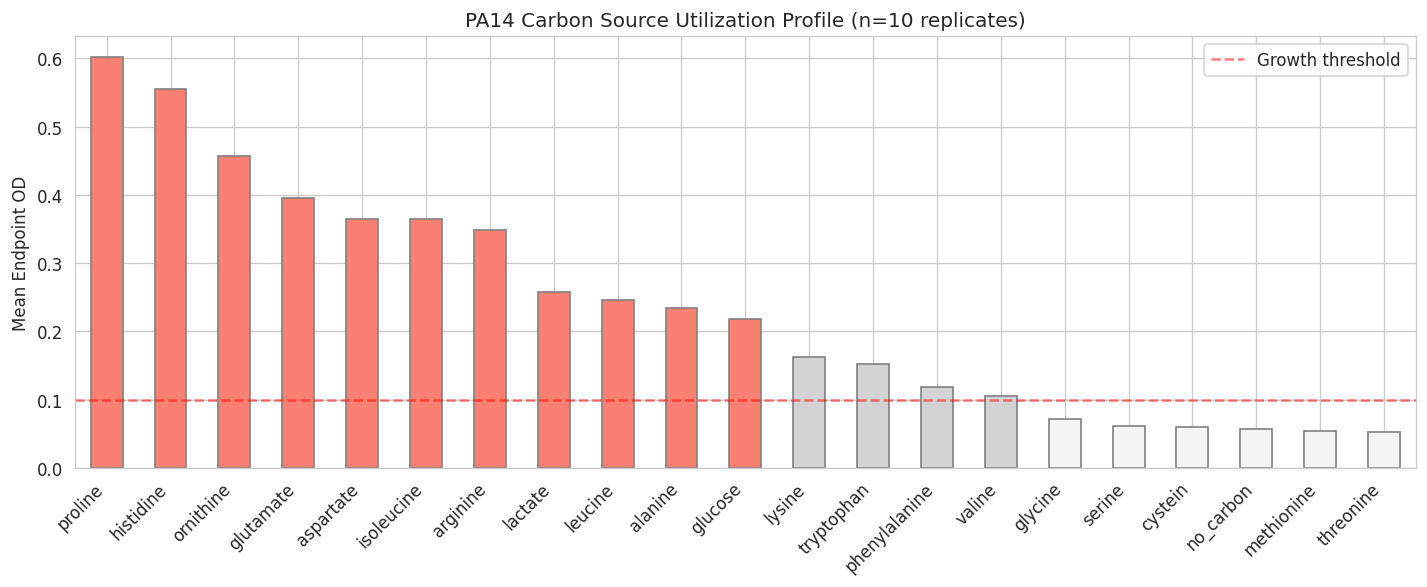


PA14 preferred substrates (OD > 0.2): ['proline', 'histidine', 'ornithine', 'glutamate', 'aspartate', 'isoleucine', 'arginine', 'lactate', 'leucine', 'alanine', 'glucose']
PA14 poor/no growth (OD < 0.08): ['glycine', 'serine', 'cystein', 'no_carbon', 'methionine', 'threonine']


In [15]:
# PA14 carbon source preference profile
pa14 = cu_numeric[cu_numeric.asma_id.str.contains('PA14', case=False, na=False)]
pa14_mean = pa14[carbon_sources].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['salmon' if v > 0.2 else 'lightgrey' if v > 0.1 else 'whitesmoke' 
          for v in pa14_mean.values]
pa14_mean.plot.bar(ax=ax, color=colors, edgecolor='grey')
ax.set_ylabel('Mean Endpoint OD')
ax.set_title('PA14 Carbon Source Utilization Profile (n={} replicates)'.format(len(pa14)))
ax.axhline(0.1, color='red', ls='--', alpha=0.5, label='Growth threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGS / '01_pa14_carbon_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# Define PA14 preferred substrates (OD > 0.2)
pa14_preferred = pa14_mean[pa14_mean > 0.2].index.tolist()
pa14_poor = pa14_mean[pa14_mean < 0.08].index.tolist()
print(f'\nPA14 preferred substrates (OD > 0.2): {pa14_preferred}')
print(f'PA14 poor/no growth (OD < 0.08): {pa14_poor}')

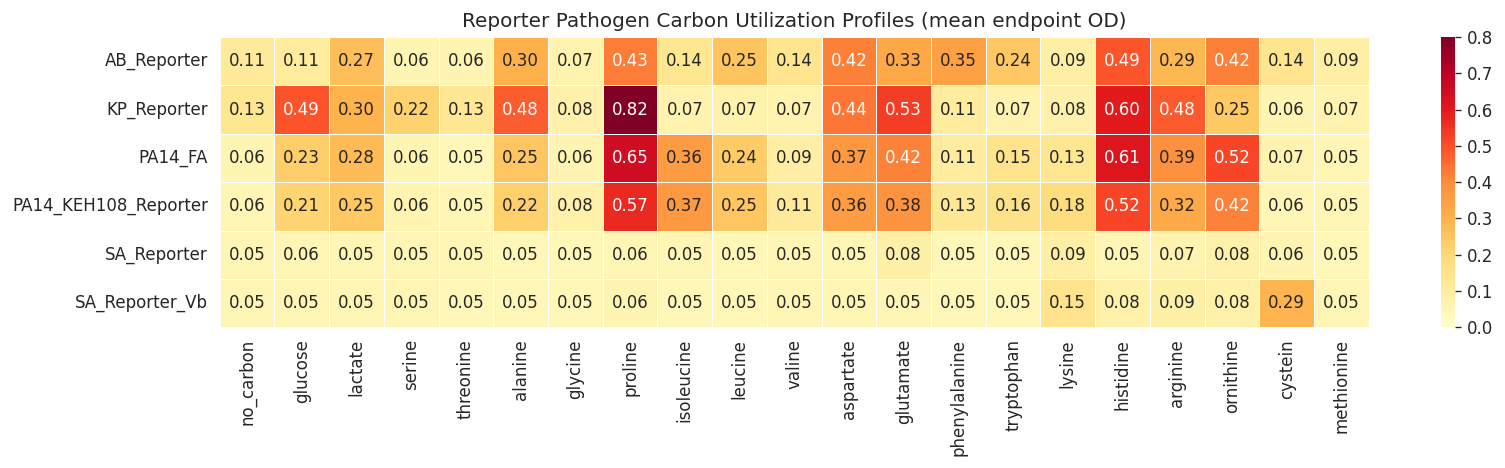

In [16]:
# Heatmap: all reporters' carbon utilization
reporter_ids = reporters.asma_id.unique()
reporter_means = reporters.groupby('asma_id')[carbon_sources].mean()

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(reporter_means, cmap='YlOrRd', annot=True, fmt='.2f', 
            linewidths=0.5, ax=ax, vmin=0, vmax=0.8)
ax.set_title('Reporter Pathogen Carbon Utilization Profiles (mean endpoint OD)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGS / '01_reporter_carbon_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

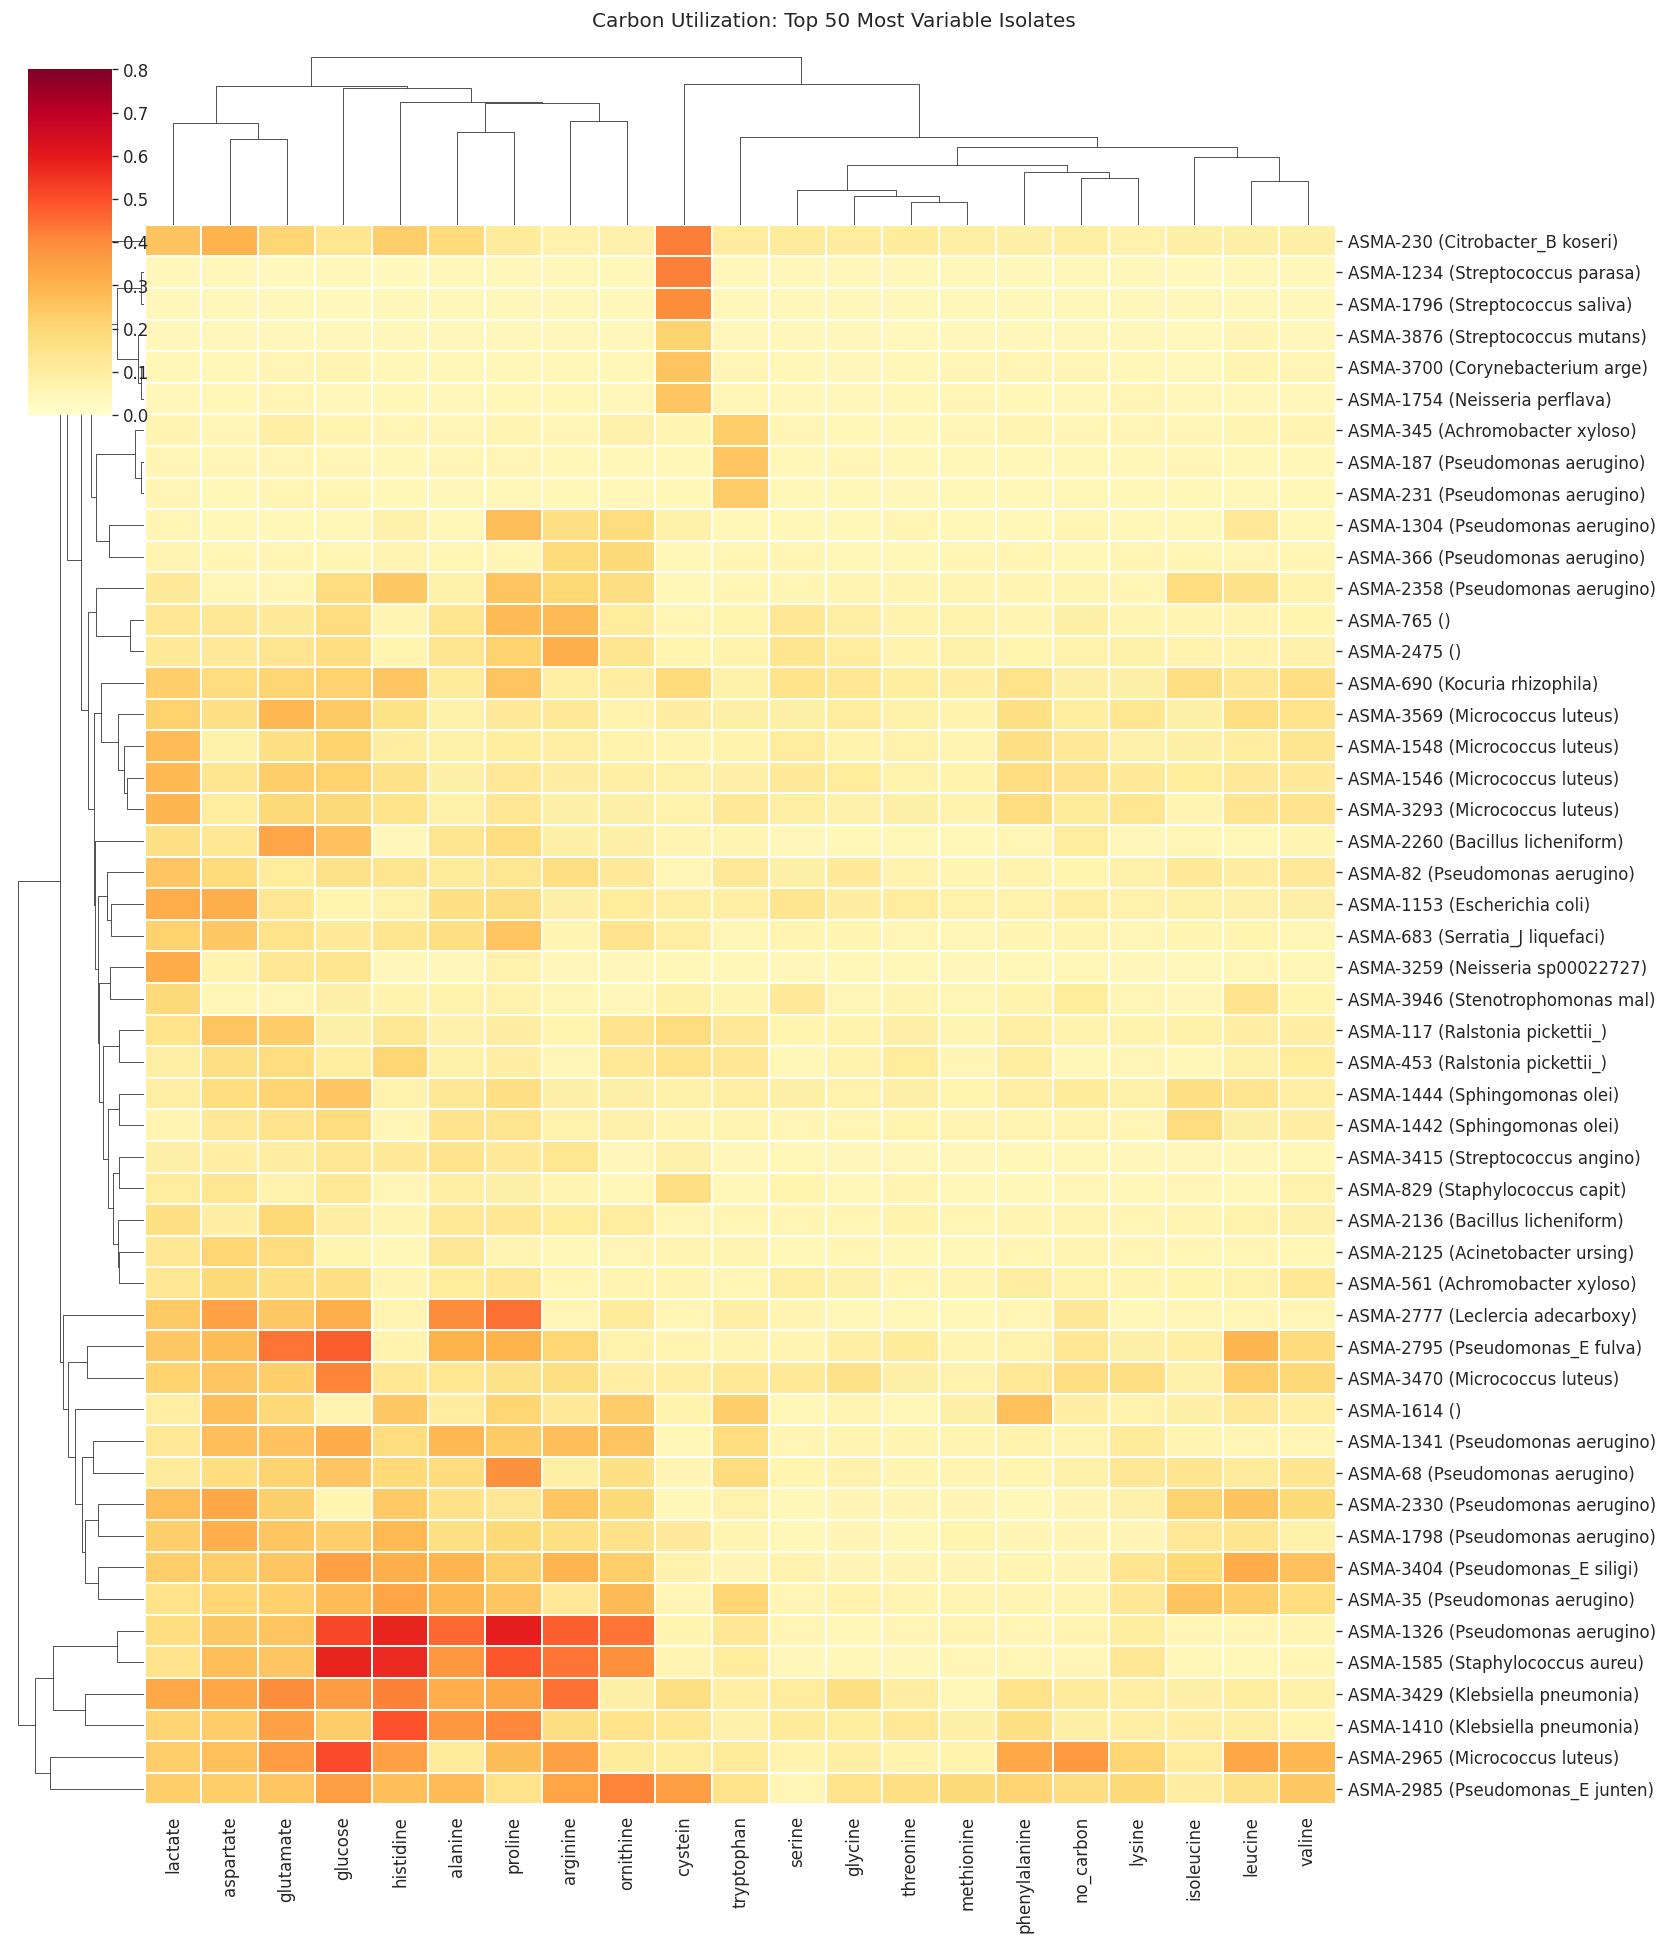

In [17]:
# Candidate isolate carbon utilization — mean per isolate, then cluster
cand_mean = candidates.groupby('asma_id')[carbon_sources].mean()
# Merge with species
cand_mean = cand_mean.merge(isolates[['asma_id', 'species', 'genus']].drop_duplicates(), 
                            left_index=True, right_on='asma_id').set_index('asma_id')

# Clustermap of top 50 isolates (by variance in carbon use)
cand_var = cand_mean[carbon_sources].var(axis=1).sort_values(ascending=False)
top50 = cand_var.head(50).index
plot_df = cand_mean.loc[top50, carbon_sources]

# Label rows with species
row_labels = [f"{idx} ({cand_mean.loc[idx, 'species'][:20]})" for idx in plot_df.index]
plot_df.index = row_labels

g = sns.clustermap(plot_df, cmap='YlOrRd', figsize=(14, 16), 
                   linewidths=0.2, vmin=0, vmax=0.8,
                   xticklabels=True, yticklabels=True,
                   dendrogram_ratio=0.1)
g.fig.suptitle('Carbon Utilization: Top 50 Most Variable Isolates', y=1.01)
plt.savefig(FIGS / '01_carbon_util_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Data Coverage & Overlap

How many isolates have data across the different assay types? The core analysis requires isolates with **both** inhibition scores and carbon utilization data.

In [18]:
# Collect isolate IDs per data type
inh_ids = set(inhibition.asma_id.unique())
cu_ids = set(candidates.asma_id.unique())  # exclude reporters
gc_ids = set(growth_fitted.asma_id.unique())

# Bridge: which isolate species appear in metagenomics?
bridge_species = set(bridge.isolate_taxon.unique())

print(f'Isolates with inhibition data:        {len(inh_ids)}')
print(f'Isolates with carbon utilization:      {len(cu_ids)}')
print(f'Isolates with growth curves:           {len(gc_ids)}')
print(f'Isolate taxa linked to metagenomics:   {len(bridge_species)}')
print(f'\nOverlaps:')
print(f'  Inhibition ∩ Carbon util:            {len(inh_ids & cu_ids)}')
print(f'  Inhibition ∩ Growth curves:          {len(inh_ids & gc_ids)}')
print(f'  Carbon util ∩ Growth curves:         {len(cu_ids & gc_ids)}')
print(f'  All three:                           {len(inh_ids & cu_ids & gc_ids)}')

Isolates with inhibition data:        220
Isolates with carbon utilization:      429
Isolates with growth curves:           32
Isolate taxa linked to metagenomics:   180

Overlaps:
  Inhibition ∩ Carbon util:            142
  Inhibition ∩ Growth curves:          29
  Carbon util ∩ Growth curves:         31
  All three:                           29


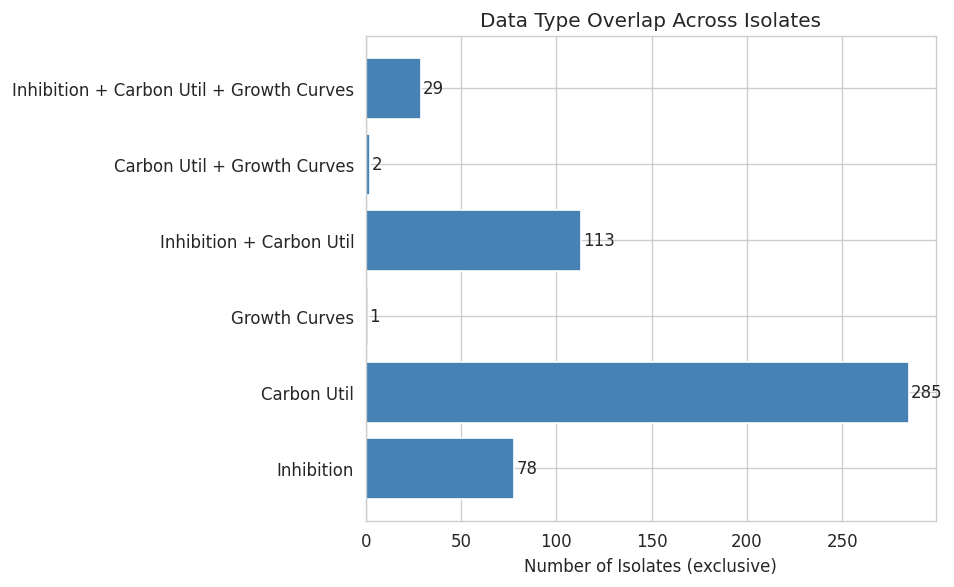

In [19]:
# Upset-style summary
from itertools import combinations

sets = {'Inhibition': inh_ids, 'Carbon Util': cu_ids, 'Growth Curves': gc_ids}
fig, ax = plt.subplots(figsize=(8, 5))

labels = []
sizes = []
for r in range(1, 4):
    for combo in combinations(sets.keys(), r):
        intersect = set.intersection(*[sets[k] for k in combo])
        # Exclusive to this combination
        others = [sets[k] for k in sets.keys() if k not in combo]
        if others:
            exclusive = intersect - set.union(*others)
        else:
            exclusive = intersect
        if len(exclusive) > 0:
            labels.append(' + '.join(combo))
            sizes.append(len(exclusive))

ax.barh(range(len(labels)), sizes, color='steelblue')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Isolates (exclusive)')
ax.set_title('Data Type Overlap Across Isolates')
for i, v in enumerate(sizes):
    ax.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.savefig(FIGS / '01_data_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Build Master Analysis Table

Merge inhibition scores, carbon utilization, and taxonomy into a single analysis-ready table. This is the foundation for all downstream notebooks.

In [20]:
# Best inhibition per isolate (across all conditions)
best_inh_df = inhibition.groupby('asma_id').agg(
    best_pct_inhibition=('pct_inh', 'max'),
    mean_pct_inhibition_all=('pct_inh', 'mean'),
    n_conditions=('pct_inh', 'count')
).reset_index()

# Mean carbon utilization per isolate
cu_mean = candidates.groupby('asma_id')[carbon_sources].mean().reset_index()

# Taxonomy from isolate catalog
tax_cols = ['asma_id', 'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species',
            'closest_genome_reference', 'closest_genome_ani', 'completeness_checkm2',
            'contamination_checkm2', 'genome_size_mb', 'gc_content', 
            'total_coding_sequences', 'strain_group', 'representative']
tax = isolates[tax_cols].drop_duplicates(subset='asma_id')

# Merge: start with all isolates that have carbon utilization
master = cu_mean.merge(tax, on='asma_id', how='left')
master = master.merge(best_inh_df, on='asma_id', how='left')

# Flag data availability
master['has_inhibition'] = master.asma_id.isin(inh_ids)
master['has_growth_curves'] = master.asma_id.isin(gc_ids)

# Compute metabolic overlap with PA14
pa14_profile = pa14[carbon_sources].mean()
# Weighted overlap: sum of min(commensal_OD, PA14_OD) across substrates / sum(PA14_OD)
pa_total = pa14_profile.drop('no_carbon').sum()
overlap_scores = []
for _, row in master.iterrows():
    overlap = sum(min(row[cs], pa14_profile[cs]) for cs in carbon_sources if cs != 'no_carbon')
    overlap_scores.append(overlap / pa_total if pa_total > 0 else 0)
master['metabolic_overlap_pa14'] = overlap_scores

print(f'Master table: {len(master)} isolates × {len(master.columns)} columns')
print(f'With inhibition data: {master.has_inhibition.sum()}')
print(f'With growth curves: {master.has_growth_curves.sum()}')
print(f'\nMetabolic overlap with PA14:')
print(master.metabolic_overlap_pa14.describe().to_string())

# Save
master.to_csv(DATA / 'isolate_master.tsv', sep='\t', index=False)
print(f'\nSaved to {DATA / "isolate_master.tsv"}')

Master table: 429 isolates × 44 columns


With inhibition data: 142
With growth curves: 31

Metabolic overlap with PA14:
count    429.000000
mean       0.233315
std        0.104252
min        0.170707
25%        0.181999
50%        0.194036
75%        0.233719
max        0.865346

Saved to ../data/isolate_master.tsv


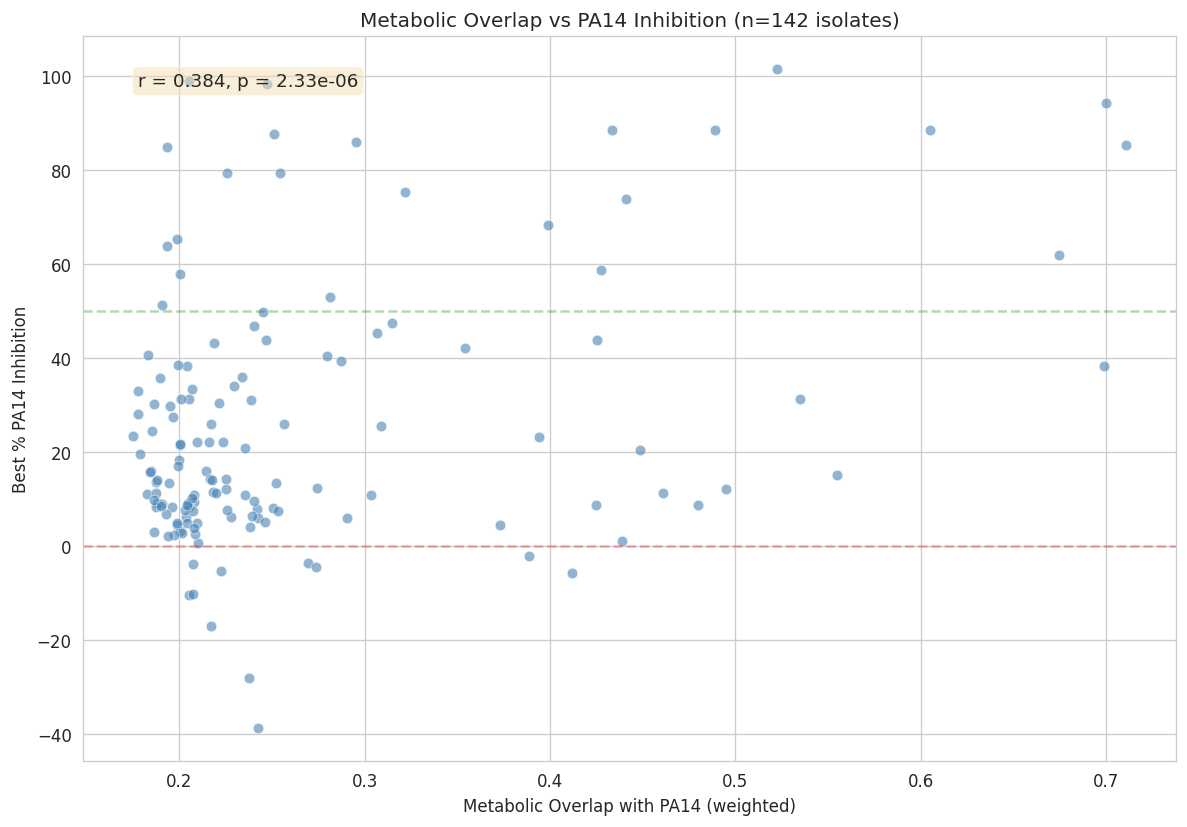

In [21]:
# Quick preview: metabolic overlap vs inhibition (for isolates with both)
both = master[master.has_inhibition].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(both.metabolic_overlap_pa14, both.best_pct_inhibition, 
                     alpha=0.6, s=40, c='steelblue', edgecolors='white', linewidth=0.5)
ax.set_xlabel('Metabolic Overlap with PA14 (weighted)')
ax.set_ylabel('Best % PA14 Inhibition')
ax.set_title(f'Metabolic Overlap vs PA14 Inhibition (n={len(both)} isolates)')
ax.axhline(0, color='red', ls='--', alpha=0.3)
ax.axhline(50, color='green', ls='--', alpha=0.3)

# Add correlation
from scipy import stats
mask = both[['metabolic_overlap_pa14', 'best_pct_inhibition']].dropna().index
r, p = stats.pearsonr(both.loc[mask, 'metabolic_overlap_pa14'], 
                       both.loc[mask, 'best_pct_inhibition'])
ax.text(0.05, 0.95, f'r = {r:.3f}, p = {p:.2e}', transform=ax.transAxes, 
        fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGS / '01_overlap_vs_inhibition_preview.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Summary statistics for the report
print('=' * 60)
print('NB01 SUMMARY')
print('=' * 60)
print(f'Isolate catalog: {len(isolates)} isolates, {isolates.species.nunique()} species')
print(f'Patient cohort: {len(patients)} samples, {patients.subject_id.nunique()} subjects')
print(f'  CF: {(patients.diagnosis=="CF").sum()}, NCFB: {(patients.diagnosis=="NCFB").sum()}')
print(f'Inhibition tested: {inhibition.asma_id.nunique()} isolates, {inh_tax.species.nunique()} species')
print(f'  Range: {inhibition.pct_inh.min():.1f}% to {inhibition.pct_inh.max():.1f}%')
print(f'Carbon utilization: {candidates.asma_id.nunique()} candidate isolates × {len(carbon_sources)-1} substrates')
print(f'Growth curves: {len(gc_ids)} isolates × {growth_fitted.columns.tolist()}')
print(f'Master table: {len(master)} isolates with carbon util + taxonomy')
print(f'  With inhibition: {master.has_inhibition.sum()}')
print(f'  With growth curves: {master.has_growth_curves.sum()}')
print(f'\nPA14 preferred substrates (OD > 0.2): {pa14_preferred}')
print(f'PA14 poor substrates (OD < 0.08): {pa14_poor}')
print(f'\nKey files saved:')
print(f'  {DATA / "isolate_master.tsv"}')

NB01 SUMMARY
Isolate catalog: 4949 isolates, 211 species
Patient cohort: 175 samples, 43 subjects
  CF: 133, NCFB: 41
Inhibition tested: 220 isolates, 91 species
  Range: -63.3% to 101.6%
Carbon utilization: 429 candidate isolates × 20 substrates
Growth curves: 32 isolates × ['asma_id', 'assay', 'condition', 'cycle', 'od_fit']
Master table: 429 isolates with carbon util + taxonomy
  With inhibition: 142
  With growth curves: 31

PA14 preferred substrates (OD > 0.2): ['proline', 'histidine', 'ornithine', 'glutamate', 'aspartate', 'isoleucine', 'arginine', 'lactate', 'leucine', 'alanine', 'glucose']
PA14 poor substrates (OD < 0.08): ['glycine', 'serine', 'cystein', 'no_carbon', 'methionine', 'threonine']

Key files saved:
  ../data/isolate_master.tsv
